In [33]:
!pip install pandas_ta stockstats

In [34]:
# === FIX #6: Reproducibility — set all random seeds ===
# Without fixing seeds, every run randomly initializes weights, shuffles batches, etc.
# This alone can shift MSE/MAE noticeably between runs, making it hard to know whether
# a metric difference vs. the paper is a real methodological gap or just random variance.
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Forces TensorFlow ops to behave deterministically on CPU (paper also ran CPU-only).
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow op-level determinism enabled.")
except Exception as e:
    print(f"Could not enable full op determinism (TF version dependent): {e}")

print(f"Global random seed set to {SEED} (python `random`, numpy, tensorflow).")
print("Re-running this notebook end-to-end should now give the same numbers each time.")


TensorFlow op-level determinism enabled.
Global random seed set to 42 (python `random`, numpy, tensorflow).
Re-running this notebook end-to-end should now give the same numbers each time.


In [35]:
import yfinance as yf

# Define the ticker symbol for Apple
ticker_symbol = 'MSFT'

# Download OHLCV data for the specified date range
df = yf.download(ticker_symbol, start='2012-03-01', end='2024-03-01')

# Display the first few rows of the downloaded data
print(df.tail())

/tmp/ipykernel_5306/1952811765.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start='2012-03-01', end='2024-03-01')
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-02-23  403.263580  408.688376  401.917211  408.501680  16295900
2024-02-26  400.511932  405.052255  400.335014  404.364315  16193500
2024-02-27  400.452911  401.278422  396.885507  400.954096  14835800
2024-02-28  400.688782  402.241521  398.330176  401.140841  13183100
2024-02-29  406.506714  407.057054  398.919846  401.592940  31947300


In [36]:
df.columns = df.columns.get_level_values(0)
df.columns.name = None # Explicitly remove the name of the column index
df = df.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Volume': 'volume'})
display(df.tail())

,close,high,low,open,volume
Date,,,,,
2024-02-23,403.263580,408.688376,401.917211,408.501680,16295900
2024-02-26,400.511932,405.052255,400.335014,404.364315,16193500
2024-02-27,400.452911,401.278422,396.885507,400.954096,14835800
2024-02-28,400.688782,402.241521,398.330176,401.140841,13183100
2024-02-29,406.506714,407.057054,398.919846,401.592940,31947300


In [37]:
df

,close,high,low,open,volume
Date,,,,,
2012-03-01,25.342161,25.420643,24.996836,25.059622,77344100
2012-03-02,25.177347,25.459883,25.114559,25.357858,47314200
2012-03-05,24.957590,25.153798,24.816322,25.122404,45240000
2012-03-06,24.769230,25.098858,24.714292,24.753534,51932900
2012-03-07,24.988977,25.051764,24.745681,24.855556,34340400
...,...,...,...,...,...
2024-02-23,403.263580,408.688376,401.917211,408.501680,16295900
2024-02-26,400.511932,405.052255,400.335014,404.364315,16193500
2024-02-27,400.452911,401.278422,396.885507,400.954096,14835800


In [38]:
df.to_csv(f'{ticker_symbol}_ohlcv_data.csv')
print("DataFrame saved to msft_ohlcv_data.csv")

DataFrame saved to msft_ohlcv_data.csv


## Project

In [39]:
import pandas as pd

df = pd.read_csv(f'{ticker_symbol}_ohlcv_data.csv')
df.head()

,Date,close,high,low,open,volume
0,2012-03-01,25.342161,25.420643,24.996836,25.059622,77344100
1,2012-03-02,25.177347,25.459883,25.114559,25.357858,47314200
2,2012-03-05,24.957590,25.153798,24.816322,25.122404,45240000
3,2012-03-06,24.769230,25.098858,24.714292,24.753534,51932900
4,2012-03-07,24.988977,25.051764,24.745681,24.855556,34340400


In [40]:
if 'Date' in df.columns:
    df.rename(columns={'Date': 'date'}, inplace=True)

df.tail()

,date,close,high,low,open,volume
3014,2024-02-23,403.263580,408.688376,401.917211,408.501680,16295900
3015,2024-02-26,400.511932,405.052255,400.335014,404.364315,16193500
3016,2024-02-27,400.452911,401.278422,396.885507,400.954096,14835800
3017,2024-02-28,400.688782,402.241521,398.330176,401.140841,13183100
3018,2024-02-29,406.506714,407.057054,398.919846,401.592940,31947300


## Outlier Removal (on raw OHLCV — before feature engineering)
Rows where **any** of the 5 OHLCV columns (open, high, low, close, volume) falls below
its Q1 (25th percentile) or above its Q3 (75th percentile) are dropped entirely.

This is done **here**, on the raw data, **before** any technical indicators are computed —
so the indicators are built only on the already-cleaned price data.


In [41]:
import numpy as np

print("--- Outlier Removal on raw OHLCV data (before feature engineering) ---")
print("Rule: remove any row where ANY of the 5 OHLCV columns is below Q1 or above Q3")

# Only check the 5 raw OHLCV columns — nothing else exists yet at this point
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']

# Calculate Q1 (25th percentile) and Q3 (75th percentile) on all available OHLCV data
Q1 = df[ohlcv_cols].quantile(0.25)
Q3 = df[ohlcv_cols].quantile(0.75)

print(f"\nQ1 (25th percentile) per column:")
print(Q1)
print(f"\nQ3 (75th percentile) per column:")
print(Q3)

# Mark a row as outlier if ANY ohlcv column falls below Q1 or above Q3 in that row
mask_outlier_rows = (
    (df[ohlcv_cols] < Q1) | (df[ohlcv_cols] > Q3)
).any(axis=1)

rows_before = len(df)
df = df[~mask_outlier_rows].reset_index(drop=True)
rows_after  = len(df)

print(f"\nRows before outlier removal : {rows_before:,}")
print(f"Rows removed                : {rows_before - rows_after:,}")
print(f"Rows remaining              : {rows_after:,}")
print(f"\ndf shape after OHLCV outlier removal: {df.shape}")


--- Outlier Removal on raw OHLCV data (before feature engineering) ---
Rule: remove any row where ANY of the 5 OHLCV columns is below Q1 or above Q3

Q1 (25th percentile) per column:
open      3.891773e+01
high      3.926240e+01
low       3.858128e+01
close     3.888489e+01
volume    2.251925e+07
Name: 0.25, dtype: float64

Q3 (75th percentile) per column:
open      2.222516e+02
high      2.252821e+02
low       2.198133e+02
close     2.221354e+02
volume    3.778655e+07
Name: 0.75, dtype: float64

Rows before outlier removal : 3,019
Rows removed                : 2,256
Rows remaining              : 763

df shape after OHLCV outlier removal: (763, 6)


Add some feature engineering column

In [42]:

import pandas as pd # Import pandas as it's used in the function signature and manual calculations
from stockstats import StockDataFrame # This import should come after pandas to ensure it's available

def compute_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    42 technical indicators matching Table 4 of Farhadi et al. (2025).
    Stockstats used for all supported indicators.
    Manual calculation only for: Elder Ray, ROC, OBV, -DI (not in Stockstats).
    """

    # Ensure 'Date' column is converted to datetime and renamed to 'date'
    # This handles cases where 'Date' might be a column instead of an index, or not yet datetime.
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.rename(columns={'Date': 'date'}, inplace=True)
    elif 'date' in df.columns: # If already 'date' but not datetime (e.g., loaded from CSV as object)
        df['date'] = pd.to_datetime(df['date'])

    # Set 'date' as index if it's currently a column and not already the index
    if 'date' in df.columns and not df.index.name == 'date':
        df.set_index('date', inplace=True)

    # Rename 'volumn' to 'volume' for stockstats compatibility
    if 'volumn' in df.columns:
        df.rename(columns={'volumn': 'volume'}, inplace=True)

    # Ensure all column names are lowercase as required by stockstats
    df.columns = [col.lower() for col in df.columns]

    # 2. Initialize StockDataFrame
    # This wrapper allows for automatic calculation of technical indicators
    # Using df.copy() to avoid modifying the original df in place before retype if desired, but retype creates a new object
    stock = StockDataFrame.retype(df.copy())

    # ── TREND FOLLOWING (9) ──────────────────────────────────────────
    stock['close_30_sma']      # SMA 30
    stock['close_30_ema']      # EMA 30
    stock['supertrend']      # supertrend
    stock['cti']       # CTI
    stock['vwma']              # VWMA
    stock['close_20_lrma']     # LRMA 20
    stock['kama']              # KAMA
    stock['ichimoku']          # Ichimoku

    # Elder Ray — manual (not in Stockstats)
    ema13 = df['close'].ewm(span=13, adjust=False).mean()
    stock['elder_bull'] = df['high'] - ema13
    stock['elder_bear'] = df['low']  - ema13

    # ── MOMENTUM OSCILLATORS (17) ────────────────────────────────────
    stock['rsi_14']            # RSI
    stock['rsv_9']             # Raw Stochastic Value
    stock['kdjk']              # KDJ K
    stock['kdjd']              # KDJ D
    stock['kdjj']              # KDJ J
    stock['macd']              # MACD line
    stock['macds']             # MACD signal
    stock['macdh']             # MACD histogram
    stock['wr_14']             # Williams %R
    stock['cci_14']            # CCI
    stock['trix']              # TRIX
    stock['ppo']               # PPO
    stock['stochrsi']          # StochRSI
    stock['wt1']               # Wave Trend 1
    stock['wt2']               # Wave Trend 2
    stock['ao']                # Awesome Oscillator

    # ROC — manual (not in Stockstats)
    stock['roc_10'] = df['close'].pct_change(10) * 100

    # ── VOLATILITY INDICATORS (8) ────────────────────────────────────
    stock['boll']              # Bollinger mid
    stock['boll_ub']           # Bollinger upper
    stock['boll_lb']           # Bollinger lower
    stock['close_20_mstd']     # Moving Std
    stock['close_20_mvar']     # Moving Variance
    stock['tr']                # True Range
    stock['atr_14']            # ATR
    stock['chop']              # Choppiness Index

    # ── VOLUME INDICATORS (3) ────────────────────────────────────────
    stock['vr']                # Volume Ratio
    stock['mfi_14']            # Money Flow Index

    # OBV — manual (not in Stockstats)
    obv = [0]
    for i in range(1, len(df)):
        if df['close'].iloc[i] > df['close'].iloc[i-1]:
            obv.append(obv[-1] + df['volume'].iloc[i])
        elif df['close'].iloc[i] < df['close'].iloc[i-1]:
            obv.append(obv[-1] - df['volume'].iloc[i])
        else:
            obv.append(obv[-1])
    stock['obv'] = obv

    # ── OTHER INDICATORS (5) ─────────────────────────────────────────
    stock['dma']               # DMA
    stock['pdi']               # +DI

    # -DI — manual (mdi not in Stockstats)
    stock['mdi_manual'] = stock['dx'] * 0  # placeholder then recalculate
    low_diff  = df['low'].diff().apply(lambda x: -x)
    high_diff = df['high'].diff()
    minus_dm  = low_diff.where((low_diff > high_diff) & (low_diff > 0), 0)
    tr14      = stock['tr'].rolling(14).sum()
    stock['mdi_manual'] = 100 * minus_dm.rolling(14).sum() / (tr14 + 1e-9)

    stock['adx']               # ADX
    stock['adxr']              # ADXR

    result = pd.DataFrame(stock)
    # result = result.dropna(axis=1, how='all')
    # result = result.dropna()
    return result

print('Computing 42 technical indicators (Stockstats + manual for unsupported)...')

# Install stockstats if not already installed
try:
    import stockstats
except ImportError:
    !pip install stockstats
    from stockstats import StockDataFrame

df_features = compute_technical_indicators(df.copy()) # Changed raw.copy() to df.copy()
print(f'Feature matrix shape: {df_features.shape}')
print(f'Total features: {len(df_features.columns)}')

# Keep only the 5 base OHLCV + exactly the 42 indicators from Table 4
# Drop any auto-generated sub-columns Stockstats creates

BASE_COLS = ['close', 'high', 'low', 'open', 'volume']

# === FIX #5: feature-selection bug fix ===
# BUG (before fix): this list named columns ('close_5_sma', 'close_12_ema', ...) that were
# NEVER computed above (the code above computes 'close_30_sma'/'close_30_ema' instead), and
# the line that actually filtered df_features down to BASE_COLS + KEEP_INDICATORS was
# commented out. The net effect: df_features kept EVERY column StockDataFrame auto-generates
# (including internal/duplicate helper columns), not the clean 47-column set (5 OHLCV + 42
# indicators) the paper describes. That extra noise gets fed into Random Forest feature
# selection later, diluting which features actually get picked.
#
# FIX: the indicator names below now match exactly what was computed in the cell above, and
# the filtering step is no longer commented out, so df_features really is just the 47 columns.
KEEP_INDICATORS = [
    # Trend
    'close_30_sma', 'close_30_ema', 'supertrend', 'cti',
    'vwma', 'close_20_lrma', 'kama', 'ichimoku',
    'elder_bull', 'elder_bear',   # Elder Ray = 2 columns (bull + bear power)

    # Momentum (17)
    'rsi_14', 'rsv_9', 'kdjk', 'kdjd', 'kdjj',
    'macd', 'macds', 'macdh',
    'wr_14', 'cci_14', 'trix', 'ppo',
    'stochrsi', 'wt1', 'wt2', 'ao', 'roc_10',

    # Volatility (8)
    'boll', 'boll_ub', 'boll_lb',
    'close_20_mstd', 'close_20_mvar',
    'tr', 'atr_14', 'chop',

    # Volume (3)
    'vr', 'mfi_14', 'obv',

    # Other (5)
    'dma', 'pdi', 'mdi_manual', 'adx', 'adxr',
]

# Keep ONLY the base OHLCV columns + the named indicators above (this was commented out before)
keep_cols = BASE_COLS + [c for c in KEEP_INDICATORS if c in df_features.columns]
missing = [c for c in KEEP_INDICATORS if c not in df_features.columns]
if missing:
    print(f"Warning: these expected indicators were not found and will be skipped: {missing}")
df_features = df_features[keep_cols]


print(f'Final feature matrix: {df_features.shape}')
print(f'Base OHLCV cols : 5')
print(f'Indicator cols  : {len(df_features.columns) - 5}')
print(f'Total           : {len(df_features.columns)} (paper: 47 = 5 OHLCV + 42 indicators)')

Computing 42 technical indicators (Stockstats + manual for unsupported)...
Feature matrix shape: (763, 54)
Total features: 54
Final feature matrix: (763, 48)
Base OHLCV cols : 5
Indicator cols  : 43
Total           : 48 (paper: 47 = 5 OHLCV + 42 indicators)


## Dropped Nan Rows

In [43]:
df_features = df_features.iloc[30:]
print(f"DataFrame shape after dropping first 30 rows: {df_features.shape}")

DataFrame shape after dropping first 30 rows: (733, 48)


## sliding window and feture selection

Shape of df_features before dropping NaNs: (733, 48)
Shape of df_features after dropping NaNs: (733, 48)
Shape of df_features after adding target and dropping NaNs: (732, 49)
--- Random Forest on original feature set only ---
Number of original input features: 48
Feature matrix shape: (732, 48)
Target shape: (732,)
Training set size: 512 samples
Validation set size: 73 samples
Testing set size: 147 samples
Top 20 Original Features by Importance:


,Feature,Importance
5,close_30_sma,0.141499
6,close_30_ema,0.110803
2,low,0.105713
10,close_20_lrma,0.084273
1,high,0.082790
3,open,0.081992
9,vwma,0.080282
7,supertrend,0.079622
11,kama,0.064821
0,close,0.054863


/tmp/ipykernel_5306/198614245.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(20), x='Importance', y='Feature', palette='viridis')


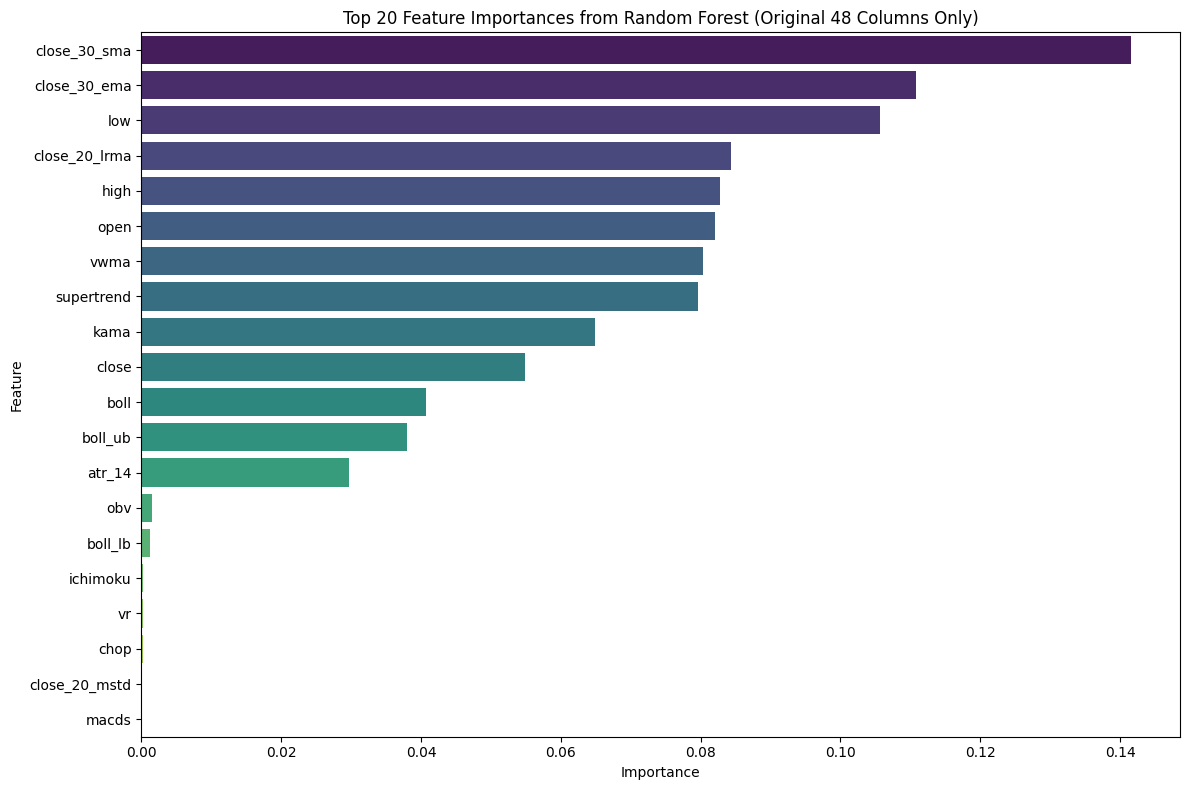

Selected original feature count: 40
X_train_selected shape: (512, 40)
X_val_selected shape: (73, 40)
X_test_selected shape: (147, 40)


In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_features is ready and clean
print(f"Shape of df_features before dropping NaNs: {df_features.shape}")
df_features_cleaned = df_features.copy().dropna()
print(f"Shape of df_features after dropping NaNs: {df_features_cleaned.shape}")

# Predict next day's close price using the ORIGINAL 48 COLUMNS only
n_steps_out_for_target_shift = 1
df_features_cleaned['target_close'] = df_features_cleaned['close'].shift(-n_steps_out_for_target_shift)
df_features_cleaned = df_features_cleaned.dropna()
print(f"Shape of df_features after adding target and dropping NaNs: {df_features_cleaned.shape}")

# Use only original columns as features (no sliding window, no lag expansion)
X = df_features_cleaned.drop(columns=['target_close'])
y = df_features_cleaned['target_close']
feature_names = X.columns.tolist()

print("--- Random Forest on original feature set only ---")
print(f"Number of original input features: {X.shape[1]}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Time-series split: 70% train, 10% validation, 20% test
n_total = len(X)
train_end = int(n_total * 0.70)
val_end = train_end + int(n_total * 0.10)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Random Forest feature importance on original columns
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 20 Original Features by Importance:")
display(feature_importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances from Random Forest (Original 48 Columns Only)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Keep top 40 features
selected_features = feature_importance_df.head(40)['Feature'].tolist()
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

print(f"Selected original feature count: {len(selected_features)}")
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_val_selected shape: {X_val_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

In [45]:
df_features_cleaned.tail(30)

,close,high,low,open,volume,close_30_sma,close_30_ema,supertrend,cti,vwma,...,chop,vr,mfi_14,obv,dma,pdi,mdi_manual,adx,adxr,target_close
date,,,,,,,,,,,,,,,,,,,,,
2020-12-08,206.351227,207.249198,203.370741,204.402451,23284100,204.226294,203.553658,192.648854,0.763993,204.046005,...,64.152097,99.652702,0.464479,2123460200,1.690635,23.172066,14.218777,2.798285,3.949381,202.329483
2020-12-09,202.329483,205.606105,201.765868,205.539243,32440600,203.892642,203.474679,192.648854,0.470642,203.828883,...,65.342000,98.365458,0.388887,2091019600,2.076400,21.506585,17.048917,2.439612,3.518018,201.106766
2020-12-10,201.106766,203.552295,200.953917,202.300873,26733300,203.581753,203.321910,192.648854,0.150828,203.601741,...,64.694454,86.086844,0.386680,2064286300,2.424252,20.602900,18.156676,3.039122,3.381191,203.724213
2020-12-11,203.724213,203.781542,199.759783,200.657754,30979400,203.396223,203.347865,192.648854,-0.098945,203.558542,...,64.671941,88.153188,0.464598,2095265700,2.706734,19.254333,15.511118,4.721008,3.763996,204.622192
2020-12-14,204.622192,206.542326,203.361223,203.571387,28798400,203.240627,203.430080,192.648854,-0.437509,203.733259,...,64.844193,105.128875,0.534242,2124064100,2.540204,22.820822,13.468697,4.017801,3.836512,204.555298
2020-12-15,204.555298,205.787610,202.749809,205.548788,27000600,203.255574,203.502675,192.648854,-0.443664,203.890840,...,64.761907,88.412912,0.528153,2097063500,2.138356,21.645233,14.762864,2.922665,3.575413,209.475052
2020-12-16,209.475052,210.267941,205.118951,205.147609,35023300,203.420855,203.887989,194.735374,0.007466,204.474502,...,58.334803,105.962086,0.603474,2132086800,2.236630,27.009484,10.734031,6.577811,4.433241,209.608734
2020-12-17,209.608734,211.013005,208.175806,210.038610,32515800,203.585827,204.257070,196.953939,0.379585,205.032401,...,54.800783,128.291675,0.603102,2164602600,2.446683,26.973462,11.253246,9.854184,5.982082,212.637024
2020-12-21,212.637024,213.983980,207.564460,207.822391,37181900,204.001648,204.797712,197.661032,0.630740,205.729665,...,47.986470,154.744908,0.608488,2201784500,2.846761,28.998809,10.656821,14.678695,8.466828,213.926651


# Applying MINMAX Scalar

In [46]:
# === FIX #2: metrics-on-scaled-data is now consistent with the paper ===
# This was flagged as a separate "problem #2" earlier, but it was really a symptom of FIX #1:
# once the target is the actual close PRICE (not a price difference), scaling it with
# MinMaxScaler and computing MSE/MAE on that [0,1]-scaled price is exactly what the paper's
# Section III-B describes ("data are not scaled, so Min-Max normalization was used to
# normalize them"). No code change needed here beyond FIX #1 — the scaler below now fits on
# price-LEVEL features/targets instead of price-CHANGE targets, which is what actually fixes
# the scale mismatch.

from sklearn.preprocessing import MinMaxScaler

print("\n--- Applying Min-Max Scaling ---")

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
# Then transform the training data
X_train_scaled = scaler.fit_transform(X_train_selected)

# Transform the validation and test data using the scaler fitted on the training data
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)



# Reshape selected flattened lag-features back into true sequences for sequence models.
# Since feature selection was done on flattened windows, we reconstruct a 3D tensor:
# (samples, timesteps, features_per_timestep)

# Define n_steps_in. Given that 'no sliding window, no lag expansion' was applied earlier,
# we treat each sample as a single timestep.
n_steps_in = 4

timesteps_for_reshape = n_steps_in
features_per_timestep_for_reshape = X_train_selected.shape[1] // n_steps_in

assert X_train_selected.shape[1] % n_steps_in == 0, (
    f"Selected feature count {X_train_selected.shape[1]} is not divisible by nstepsin={n_steps_in}. "
    "This means RF selected an arbitrary mix of lagged features, so you cannot cleanly reshape back "
    "to (timesteps, features_per_timestep)."
)

X_train_reshaped = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    timesteps_for_reshape,
    features_per_timestep_for_reshape
)
X_val_reshaped = X_val_scaled.reshape(
    X_val_scaled.shape[0],
    timesteps_for_reshape,
    features_per_timestep_for_reshape
)
X_test_reshaped = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    timesteps_for_reshape,
    features_per_timestep_for_reshape
)

print("Shape of Xtrainreshaped:", X_train_reshaped.shape)
print("Shape of Xvalreshaped:", X_val_reshaped.shape)
print("Shape of Xtestreshaped:", X_test_reshaped.shape)


print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_val_scaled: {X_val_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of X_train_reshaped: {X_train_reshaped.shape}")
print(f"Shape of X_val_reshaped: {X_val_reshaped.shape}")
print(f"Shape of X_test_reshaped: {X_test_reshaped.shape}")

print("Min-Max Scaling applied successfully to train, validation, and test sets.")


--- Applying Min-Max Scaling ---
Shape of Xtrainreshaped: (512, 4, 10)
Shape of Xvalreshaped: (73, 4, 10)
Shape of Xtestreshaped: (147, 4, 10)
Shape of X_train_scaled: (512, 40)
Shape of X_val_scaled: (73, 40)
Shape of X_test_scaled: (147, 40)
Shape of X_train_reshaped: (512, 4, 10)
Shape of X_val_reshaped: (73, 4, 10)
Shape of X_test_reshaped: (147, 4, 10)
Min-Max Scaling applied successfully to train, validation, and test sets.


# Model separately

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, LSTM, Dense, Dropout, concatenate,
    Conv1D, MaxPooling1D, Flatten, Bidirectional,
    Attention, GlobalAveragePooling1D, LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === Hyperparameters — taken directly from Table 7, applied to EVERY model ===
# Paper, Section V: "To make a fair comparison between different models, we used the same
# hyperparameters and the same technical indicators for all the methods." So these values
# are not specific to the hybrid model — every architecture below uses them identically.
learning_rate = 0.001   # Table 7: Learning rate = 1e-3
epochs        = 100     # Table 7: Number of epochs = 100
batch_size    = 30      # Table 7: Batch size = 30
gru_units     = 50      # Table 7: Number of units per module (LSTM and GRU) = 50
lstm_units    = 50      # Table 7: Number of units per module (LSTM and GRU) = 50
dense_units   = 50      # NOT specified anywhere in the paper (Table 7 omits FC layer width).
                         # Defaulted to the same value as the GRU/LSTM units since no other
                         # number is given anywhere in the text or tables.
dropout_rate  = 0.2      # Table 7: implied by "0.2 dropout rate" mentioned in Section IV text

# --- Shape info (from your already-prepared data) ---
timesteps            = X_train_reshaped.shape[1]
features_per_timestep = X_train_reshaped.shape[2]

# --- Scale target variable ---
y_scaler       = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

# --- Dict to collect results ---
all_model_results = {}

In [48]:
def evaluate_with_paper_protocol(build_fn, model_name, n_runs=10, k_folds=5):
    print(f"\n{'='*70}\n{model_name}\n{'='*70}")

    # --- (A) 10 independent runs -> held-out TEST set ---
    test_mse, test_mae, test_mape = [], [], []
    for run in range(n_runs):
        tf.keras.utils.set_random_seed(SEED + run)
        model = build_fn()
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_train_reshaped, y_train_scaled,
                  epochs=epochs, batch_size=batch_size,
                  validation_data=(X_val_reshaped, y_val_scaled),
                  callbacks=[es], verbose=0)
        y_pred = model.predict(X_test_reshaped, verbose=0)

        mse  = mean_squared_error(y_test_scaled, y_pred)
        mae  = mean_absolute_error(y_test_scaled, y_pred)
        y_test_real = y_scaler.inverse_transform(y_test_scaled)
        y_pred_real = y_scaler.inverse_transform(y_pred)
        mape = np.mean(np.abs((y_test_real - y_pred_real) / (np.abs(y_test_real) + 1e-9))) * 100

        test_mse.append(mse)
        test_mae.append(mae)
        test_mape.append(mape)
        print(f"  Run {run+1}/{n_runs}: MSE={mse:.4f} | MAE={mae:.4f} | MAPE={mape:.4f}%")

    test_mse, test_mae, test_mape = (np.array(a) for a in (test_mse, test_mae, test_mape))
    print(f"\n10-run TEST performance -> "
          f"MSE: {test_mse.mean():.4f} +/- {test_mse.std():.4f} | "
          f"MAE: {test_mae.mean():.4f} +/- {test_mae.std():.4f} | "
          f"MAPE: {test_mape.mean():.4f}% +/- {test_mape.std():.4f}%")

    # --- (B) 5-fold CV on the training set (chronological, no shuffling) ---
    kf = KFold(n_splits=k_folds, shuffle=False)
    cv_mse, cv_mae, cv_mape = [], [], []
    for fold, (tr_idx, ho_idx) in enumerate(kf.split(X_train_reshaped), start=1):
        tf.keras.utils.set_random_seed(SEED)
        model = build_fn()
        es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
        model.fit(X_train_reshaped[tr_idx], y_train_scaled[tr_idx],
                  epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)
        y_pred = model.predict(X_train_reshaped[ho_idx], verbose=0)

        mse  = mean_squared_error(y_train_scaled[ho_idx], y_pred)
        mae  = mean_absolute_error(y_train_scaled[ho_idx], y_pred)
        y_ho_real = y_scaler.inverse_transform(y_train_scaled[ho_idx])
        y_pred_real_cv = y_scaler.inverse_transform(y_pred)
        y_ho_real   = y_scaler.inverse_transform(y_train_scaled[ho_idx])
        y_pred_real = y_scaler.inverse_transform(y_pred)
        mape = np.mean(np.abs((y_ho_real - y_pred_real) / (np.abs(y_ho_real) + 1e-9))) * 100

        cv_mse.append(mse)
        cv_mae.append(mae)
        cv_mape.append(mape)
        print(f"  Fold {fold}/{k_folds}: MSE={mse:.4f} | MAE={mae:.4f} | MAPE={mape:.4f}%")

    cv_mse, cv_mae, cv_mape = (np.array(a) for a in (cv_mse, cv_mae, cv_mape))
    print(f"5-fold CV performance -> "
          f"MSE: {cv_mse.mean():.4f} +/- {cv_mse.std():.4f} | "
          f"MAE: {cv_mae.mean():.4f} +/- {cv_mae.std():.4f} | "
          f"MAPE: {cv_mape.mean():.4f}% +/- {cv_mape.std():.4f}%")

    all_model_results[model_name] = {
        'MSE':      test_mse.mean(),  'MSE_std':  test_mse.std(),
        'MAE':      test_mae.mean(),  'MAE_std':  test_mae.std(),
        'MAPE':     test_mape.mean(), 'MAPE_std': test_mape.std(),
        'CV_MSE':   cv_mse.mean(),
        'CV_MAE':   cv_mae.mean(),
        'CV_MAPE':  cv_mape.mean(),
    }

In [49]:
def build_simple_lstm_model():
    inputs = Input(shape=(timesteps, features_per_timestep))

    x = LSTM(lstm_units, return_sequences=False)(inputs)
    x = Dropout(0.5)(x)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(1)(x)

    m = Model(inputs=inputs, outputs=outputs)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='mean_squared_error'
    )
    return m

evaluate_with_paper_protocol(build_simple_lstm_model, "Simple-LSTM")


Simple-LSTM
  Run 1/10: MSE=0.2771 | MAE=0.5025 | MAPE=22.1599%
  Run 2/10: MSE=0.4933 | MAE=0.6845 | MAPE=30.3679%
  Run 3/10: MSE=0.3239 | MAE=0.5509 | MAPE=24.4153%
  Run 4/10: MSE=0.3204 | MAE=0.5493 | MAPE=24.3657%
  Run 5/10: MSE=0.4819 | MAE=0.6781 | MAPE=30.1210%
  Run 6/10: MSE=0.6941 | MAE=0.8200 | MAPE=36.5329%
  Run 7/10: MSE=0.1714 | MAE=0.3875 | MAPE=17.0019%
  Run 8/10: MSE=0.6367 | MAE=0.7832 | MAPE=34.8355%
  Run 9/10: MSE=0.2097 | MAE=0.4321 | MAPE=19.0318%
  Run 10/10: MSE=0.6895 | MAE=0.8179 | MAPE=36.4400%

10-run TEST performance -> MSE: 0.4298 +/- 0.1867 | MAE: 0.6206 +/- 0.1504 | MAPE: 27.5272% +/- 6.7837%
  Fold 1/5: MSE=0.0007 | MAE=0.0242 | MAPE=5.1180%
  Fold 2/5: MSE=0.0042 | MAE=0.0605 | MAPE=11.4792%
  Fold 3/5: MSE=0.0066 | MAE=0.0781 | MAPE=10.8193%
  Fold 4/5: MSE=0.0261 | MAE=0.1580 | MAPE=15.2021%
  Fold 5/5: MSE=0.0614 | MAE=0.2398 | MAPE=19.4863%
5-fold CV performance -> MSE: 0.0198 +/- 0.0226 | MAE: 0.1121 +/- 0.0774 | MAPE: 12.4210% +/- 4.7841%


In [50]:
def build_lstm_model():
    inputs = Input(shape=(timesteps, features_per_timestep))

    x = LSTM(lstm_units, return_sequences=False)(inputs)
    x = Dropout(0.4)(x)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(1)(x)

    m = Model(inputs=inputs, outputs=outputs)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='mean_squared_error'
    )
    return m

evaluate_with_paper_protocol(build_lstm_model, "LSTM")


LSTM
  Run 1/10: MSE=0.3326 | MAE=0.5564 | MAPE=24.6046%
  Run 2/10: MSE=0.5100 | MAE=0.6955 | MAPE=30.8525%
  Run 3/10: MSE=0.0993 | MAE=0.2893 | MAPE=12.6646%
  Run 4/10: MSE=0.0730 | MAE=0.2407 | MAPE=10.5001%
  Run 5/10: MSE=0.2295 | MAE=0.4571 | MAPE=20.1541%
  Run 6/10: MSE=0.3304 | MAE=0.5564 | MAPE=24.6467%
  Run 7/10: MSE=0.0816 | MAE=0.2563 | MAPE=11.1631%
  Run 8/10: MSE=0.3037 | MAE=0.5310 | MAPE=23.4733%
  Run 9/10: MSE=0.1694 | MAE=0.3854 | MAPE=16.9528%
  Run 10/10: MSE=0.4761 | MAE=0.6778 | MAPE=30.1547%

10-run TEST performance -> MSE: 0.2606 +/- 0.1494 | MAE: 0.4646 +/- 0.1583 | MAPE: 20.5167% +/- 7.1031%
  Fold 1/5: MSE=0.0008 | MAE=0.0265 | MAPE=5.4938%
  Fold 2/5: MSE=0.0026 | MAE=0.0457 | MAPE=8.7021%
  Fold 3/5: MSE=0.0028 | MAE=0.0495 | MAPE=6.9249%
  Fold 4/5: MSE=0.0120 | MAE=0.1057 | MAPE=10.1535%
  Fold 5/5: MSE=0.0506 | MAE=0.2144 | MAPE=17.3378%
5-fold CV performance -> MSE: 0.0138 +/- 0.0188 | MAE: 0.0884 +/- 0.0683 | MAPE: 9.7224% +/- 4.1214%


In [51]:
def build_simple_gru_model():
    inputs = Input(shape=(timesteps, features_per_timestep))

    x = GRU(gru_units, return_sequences=False)(inputs)
    x = Dropout(0.4)(x)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(1)(x)

    m = Model(inputs=inputs, outputs=outputs)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='mean_squared_error'
    )
    return m

evaluate_with_paper_protocol(build_simple_gru_model, "GRU")


GRU
  Run 1/10: MSE=0.3061 | MAE=0.5399 | MAPE=23.9647%
  Run 2/10: MSE=0.3051 | MAE=0.5391 | MAPE=23.9286%
  Run 3/10: MSE=0.2963 | MAE=0.5304 | MAPE=23.5364%
  Run 4/10: MSE=0.2501 | MAE=0.4794 | MAPE=21.1964%
  Run 5/10: MSE=0.2838 | MAE=0.5190 | MAPE=23.0269%
  Run 6/10: MSE=0.1376 | MAE=0.3590 | MAPE=15.9303%
  Run 7/10: MSE=0.3589 | MAE=0.5846 | MAPE=25.9463%
  Run 8/10: MSE=0.1815 | MAE=0.3978 | MAPE=17.4743%
  Run 9/10: MSE=0.2981 | MAE=0.5137 | MAPE=22.6113%
  Run 10/10: MSE=0.3333 | MAE=0.5657 | MAPE=25.1451%

10-run TEST performance -> MSE: 0.2751 +/- 0.0645 | MAE: 0.5029 +/- 0.0684 | MAPE: 22.2760% +/- 3.0666%
  Fold 1/5: MSE=0.0003 | MAE=0.0113 | MAPE=2.2952%
  Fold 2/5: MSE=0.0016 | MAE=0.0352 | MAPE=6.7049%
  Fold 3/5: MSE=0.0011 | MAE=0.0281 | MAPE=3.9484%
  Fold 4/5: MSE=0.0142 | MAE=0.1162 | MAPE=11.1923%
  Fold 5/5: MSE=0.0412 | MAE=0.1886 | MAPE=15.1614%
5-fold CV performance -> MSE: 0.0117 +/- 0.0156 | MAE: 0.0759 +/- 0.0670 | MAPE: 7.8604% +/- 4.7332%


In [52]:
from tensorflow.keras.layers import Input, GRU, LSTM, Dropout, Dense, Flatten
from tensorflow.keras.models import Model
import tensorflow as tf

# Hyperparameters (Table 7 in the paper)
GRU_UNITS = 50
LSTM_UNITS = 50
DENSE_UNITS = 50
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001


def build_hybrid_model():
    # 'timesteps' and 'features_per_timestep' come from the actual data shape
    # (defined in earlier cells), not hardcoded values.
    inputs = Input(shape=(timesteps, features_per_timestep))

    # --- GRU module 1 ---
    x = GRU(units=GRU_UNITS, return_sequences=True, name="gru_1")(inputs)
    x = Dropout(DROPOUT_RATE, name="gru_dropout_1")(x)

    # --- GRU module 2 ---
    x = GRU(units=GRU_UNITS, return_sequences=True, name="gru_2")(x)
    x = Dropout(DROPOUT_RATE, name="gru_dropout_2")(x)

    # --- LSTM module 1 ---
    x = LSTM(units=LSTM_UNITS, return_sequences=False, name="lstm_1")(x)
    x = Dropout(DROPOUT_RATE, name="lstm_dropout_1")(x)

    # --- Fully connected head ---
    x = Flatten(name="flatten")(x)
    x = Dense(units=DENSE_UNITS, activation="relu", name="fc_dense")(x)
    x = Dropout(DROPOUT_RATE, name="fc_dropout")(x)
    outputs = Dense(units=1, activation="sigmoid", name="regression_output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Hybrid_LSTM_GRU")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mean_squared_error",
        metrics=["mae"],
    )
    return model


evaluate_with_paper_protocol(build_hybrid_model, "Hybrid_LSTM-GRU")


Hybrid_LSTM-GRU
  Run 1/10: MSE=0.6456 | MAE=0.7869 | MAPE=34.9571%
  Run 2/10: MSE=0.6833 | MAE=0.8106 | MAPE=36.0329%
  Run 3/10: MSE=0.6514 | MAE=0.7907 | MAPE=35.1289%
  Run 4/10: MSE=0.6527 | MAE=0.7915 | MAPE=35.1690%
  Run 5/10: MSE=0.6496 | MAE=0.7895 | MAPE=35.0751%
  Run 6/10: MSE=0.6470 | MAE=0.7878 | MAPE=34.9978%
  Run 7/10: MSE=0.6480 | MAE=0.7885 | MAPE=35.0288%
  Run 8/10: MSE=0.6490 | MAE=0.7891 | MAPE=35.0603%
  Run 9/10: MSE=0.7265 | MAE=0.8368 | MAPE=37.2134%
  Run 10/10: MSE=0.6461 | MAE=0.7872 | MAPE=34.9739%

10-run TEST performance -> MSE: 0.6599 +/- 0.0246 | MAE: 0.7959 +/- 0.0152 | MAPE: 35.3637% +/- 0.6856%
  Fold 1/5: MSE=0.0010 | MAE=0.0279 | MAPE=6.0510%
  Fold 2/5: MSE=0.0010 | MAE=0.0291 | MAPE=5.3993%
  Fold 3/5: MSE=0.0017 | MAE=0.0353 | MAPE=4.9440%
  Fold 4/5: MSE=0.0019 | MAE=0.0376 | MAPE=3.6613%
  Fold 5/5: MSE=0.0036 | MAE=0.0471 | MAPE=3.7101%
5-fold CV performance -> MSE: 0.0019 +/- 0.0010 | MAE: 0.0354 +/- 0.0069 | MAPE: 4.7531% +/- 0.9400%


In [63]:
# === CNN baseline — architecture taken from Table 6 (paper's report of [56]'s structure) ===
# Conv1d(32) -> Conv1d(64) -> LeakyReLU -> MaxPool -> Conv1d(128) -> LeakyReLU -> MaxPool
# -> Flatten -> Dense(256) -> LeakyReLU -> Dropout -> Dense(1)
#
# Notes on assumptions:
# - Kernel size for Conv1d layers not given in Table 6; kernel_size=3, padding='same'
#   is used, since this is the only setting that reproduces the table's exact output
#   shapes (e.g. (None,4,32) -> (None,4,64) with input timesteps=4).
# - Table implies input timesteps=4 (first Conv1d output is (None,4,32)).
# - MaxPooling1D uses padding='valid' (default) — table's shapes (4->2, 2->1) are a
#   clean halving with pool_size=2, so no extra padding is needed.
# - Table 6 row "LeakyReLu -> (None,4,128)" appears to be a typo (LeakyReLU never
#   changes shape, and the surrounding rows are (None,2,128)); treated as (None,2,128).
# - Dropout rate not specified in Table 6; kept as configurable `dropout_rate`.

def build_cnn_model():
    inputs = Input(shape=(timesteps, features_per_timestep))
    x = Conv1D(filters=32, kernel_size=3, padding='same')(inputs)
    x = Conv1D(filters=64, kernel_size=3, padding='same')(x)
    x = LeakyReLU()(x)
    x = MaxPooling1D(pool_size=2, padding='valid')(x)
    x = Dropout(0.8)(x)
    x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
    x = LeakyReLU()(x)
    x = Dropout(0.5)(x)
    x = MaxPooling1D(pool_size=2, padding='valid')(x)
    x = Dropout(0.8)(x)
    x = Flatten()(x)
    x = Dense(256)(x)
    x = LeakyReLU()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1)(x)
    m = Model(inputs=inputs, outputs=outputs)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error')
    return m

evaluate_with_paper_protocol(build_cnn_model, "CNN")


CNN
  Run 1/10: MSE=0.5698 | MAE=0.7477 | MAPE=33.4123%
  Run 2/10: MSE=0.1738 | MAE=0.4046 | MAPE=17.9915%
  Run 3/10: MSE=0.5292 | MAE=0.7181 | MAPE=32.0351%
  Run 4/10: MSE=0.5128 | MAE=0.7119 | MAPE=31.9794%
  Run 5/10: MSE=0.2310 | MAE=0.4716 | MAPE=21.0504%
  Run 6/10: MSE=0.2072 | MAE=0.4395 | MAPE=19.4906%
  Run 7/10: MSE=0.9473 | MAE=0.9652 | MAPE=43.1714%
  Run 8/10: MSE=0.0175 | MAE=0.1058 | MAPE=4.8261%
  Run 9/10: MSE=0.3196 | MAE=0.5455 | MAPE=24.2010%
  Run 10/10: MSE=0.2783 | MAE=0.5145 | MAPE=22.8729%

10-run TEST performance -> MSE: 0.3786 +/- 0.2525 | MAE: 0.5624 +/- 0.2242 | MAPE: 25.1031% +/- 10.0314%
  Fold 1/5: MSE=0.0164 | MAE=0.1260 | MAPE=26.3342%
  Fold 2/5: MSE=0.0371 | MAE=0.1904 | MAPE=35.8269%
  Fold 3/5: MSE=0.0041 | MAE=0.0510 | MAPE=6.7706%
  Fold 4/5: MSE=0.0930 | MAE=0.3026 | MAPE=29.3229%
  Fold 5/5: MSE=0.0664 | MAE=0.2515 | MAPE=20.5563%
5-fold CV performance -> MSE: 0.0434 +/- 0.0326 | MAE: 0.1843 +/- 0.0891 | MAPE: 23.7622% +/- 9.8192%


In [54]:
def build_cnn_bilstm_am_model():
    inputs = Input(shape=(timesteps, features_per_timestep))
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Dropout(0.5)(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = Dropout(0.5)(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)  # 3 consecutive Conv1D layers
    x = MaxPooling1D(pool_size=1, padding='same')(x)
    x = Dropout(0.5)(x)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x) # Changed to True to preserve sequence dimension
    x = Dropout(0.5)(x)
    # Removed the Attention layer as it is redundant for timesteps = 1
    x = GlobalAveragePooling1D()(x)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(1)(x)
    m = Model(inputs=inputs, outputs=outputs)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return m

evaluate_with_paper_protocol(build_cnn_bilstm_am_model, "CNN-BiLSTM-AM")


CNN-BiLSTM-AM
  Run 1/10: MSE=0.2108 | MAE=0.4463 | MAPE=19.7936%
  Run 2/10: MSE=0.3504 | MAE=0.5799 | MAPE=25.7886%
  Run 3/10: MSE=0.4063 | MAE=0.6251 | MAPE=27.8066%
  Run 4/10: MSE=0.6143 | MAE=0.7718 | MAPE=34.3697%
  Run 5/10: MSE=0.4672 | MAE=0.6685 | MAPE=29.6847%
  Run 6/10: MSE=0.2012 | MAE=0.4324 | MAPE=19.1326%
  Run 7/10: MSE=0.4424 | MAE=0.6516 | MAPE=28.9567%
  Run 8/10: MSE=0.2516 | MAE=0.4866 | MAPE=21.6116%
  Run 9/10: MSE=0.2318 | MAE=0.4645 | MAPE=20.5724%
  Run 10/10: MSE=0.1955 | MAE=0.4253 | MAPE=18.8548%

10-run TEST performance -> MSE: 0.3372 +/- 0.1352 | MAE: 0.5552 +/- 0.1146 | MAPE: 24.6571% +/- 5.1293%
  Fold 1/5: MSE=0.0027 | MAE=0.0469 | MAPE=10.1782%
  Fold 2/5: MSE=0.0061 | MAE=0.0731 | MAPE=13.4694%
  Fold 3/5: MSE=0.0288 | MAE=0.1634 | MAPE=22.6406%
  Fold 4/5: MSE=0.0040 | MAE=0.0548 | MAPE=5.3772%
  Fold 5/5: MSE=0.0423 | MAE=0.1888 | MAPE=15.1279%
5-fold CV performance -> MSE: 0.0168 +/- 0.0160 | MAE: 0.1054 +/- 0.0589 | MAPE: 13.3586% +/- 5.7117

In [64]:
import pandas as pd

# Ensure all_model_results is available
if 'all_model_results' in locals():
    results_df = pd.DataFrame.from_dict(all_model_results, orient='index')
    results_df.index.name = 'Model'
    print(f"\nSummary of All Model Performance on IBM stock")
    display(results_df[['MSE','MAE','MAPE']].sort_values(by=['MSE','MAE']))
else:
    print("Error: 'all_model_results' dictionary not found. Please ensure all models have been trained and evaluated.")


Summary of All Model Performance on IBM stock


,MSE,MAE,MAPE
Model,,,
LSTM,0.260563,0.464590,20.516652
GRU,0.275061,0.502864,22.276011
CNN-BiLSTM-AM,0.337160,0.555203,24.657126
CNN,0.378639,0.562422,25.103085
Simple-LSTM,0.429808,0.620590,27.527185
Hybrid_LSTM-GRU,0.659921,0.795866,35.363732


## Training Curves (Loss / RMSE / MAPE) per Model — MSFT

For every model (Simple-LSTM, LSTM, GRU, Hybrid LSTM-GRU, CNN, CNN-BiLSTM-AM) we train **one representative run** on MSFT
and record the **train vs. test** curves for three metrics every epoch, reproducing the style of Figs. 7–33 in the paper:
- **Loss (MSE)**
- **RMSE**
- **MAPE**

Each metric gets its own figure per model, with the train curve in dashed red and the test curve in dashed blue,
matching the paper's plotting convention.

In [56]:
# === Train each model once and capture per-epoch Loss / RMSE / MAPE curves (train vs test) ===
# This reproduces the plotting style of Figs. 7-33 in the paper (per-stock, per-model,
# train/test curves for Loss, RMSE, and MAPE across epochs).

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import os # Import os for path manipulation

# Custom MAPE metric that inverse-transforms the Min-Max scaled target back to
# real price scale before computing the percentage error — avoids near-zero
# denominators that blow MAPE up into the hundreds of thousands/millions.
# These variables and function need to be globally accessible if used as a Keras metric.
# Assuming y_scaler is already defined and fitted globally (which it is from previous cells).
y_min = float(y_scaler.data_min_[0])
y_max = float(y_scaler.data_max_[0])

def mape_real_scale(y_true, y_pred):
    y_true_real = y_true * (y_max - y_min) + y_min
    y_pred_real = y_pred * (y_max - y_min) + y_min
    return tf.reduce_mean(tf.abs((y_true_real - y_pred_real) / (tf.abs(y_true_real) + 1e-9))) * 100

mape_real_scale.__name__ = 'mape'   # so history.history keys stay 'mape' / 'val_mape'

def train_with_curves(build_fn, model_name, epochs=epochs, batch_size=batch_size, seed=SEED):
    """
    Trains ONE instance of the given model (no early stopping, no k-fold — this is purely
    for visualizing the train/test learning curves, not for the paper's reported metrics
    which come from evaluate_with_paper_protocol's 10-run + 5-fold procedure).

    Returns the Keras History object with keys:
    'loss', 'val_loss', 'rmse', 'val_rmse', 'mape', 'val_mape'
    """
    tf.keras.utils.set_random_seed(seed)
    model = build_fn()

    # Recompile so every model reports RMSE and MAPE alongside the MSE loss every epoch,
    # regardless of what the original build_fn's compile() call specified.
    model.compile(
        optimizer=model.optimizer,
        loss='mean_squared_error',
        metrics=[RootMeanSquaredError(name='rmse'), mape_real_scale]
    )

    history = model.fit(
        X_train_reshaped, y_train_scaled,
        validation_data=(X_test_reshaped, y_test_scaled),
        epochs=epochs, batch_size=batch_size, verbose=0
    )
    return history


def plot_curves(history, model_name, ticker=ticker_symbol, save_dir='.'):
    """Plots Loss, RMSE, and MAPE (train vs test) as three separate figures, paper-style.
    Modified to plot all three curves in a single figure for one model.
    """
    h = history.history
    metric_specs = [
        ('loss', 'val_loss', 'Loss'),
        ('rmse', 'val_rmse', 'Root Mean Square Error'),
        ('mape', 'val_mape', 'Mean Absolute Percentage Error'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Create a figure with 3 subplots
    fig.suptitle(f'{ticker} {model_name} Training Curves', fontsize=16)

    for i, (train_key, val_key, title) in enumerate(metric_specs):
        ax = axes[i]
        ax.plot(h[train_key], 'r--', label='train')
        ax.plot(h[val_key], 'b--', label='test')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap

    # Save the combined figure to the specified directory
    filename = f"{ticker}_{model_name}_all_curves.png"
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath)
    plt.show()


Training LSTM on MSFT to capture Loss/RMSE/MAPE curves...


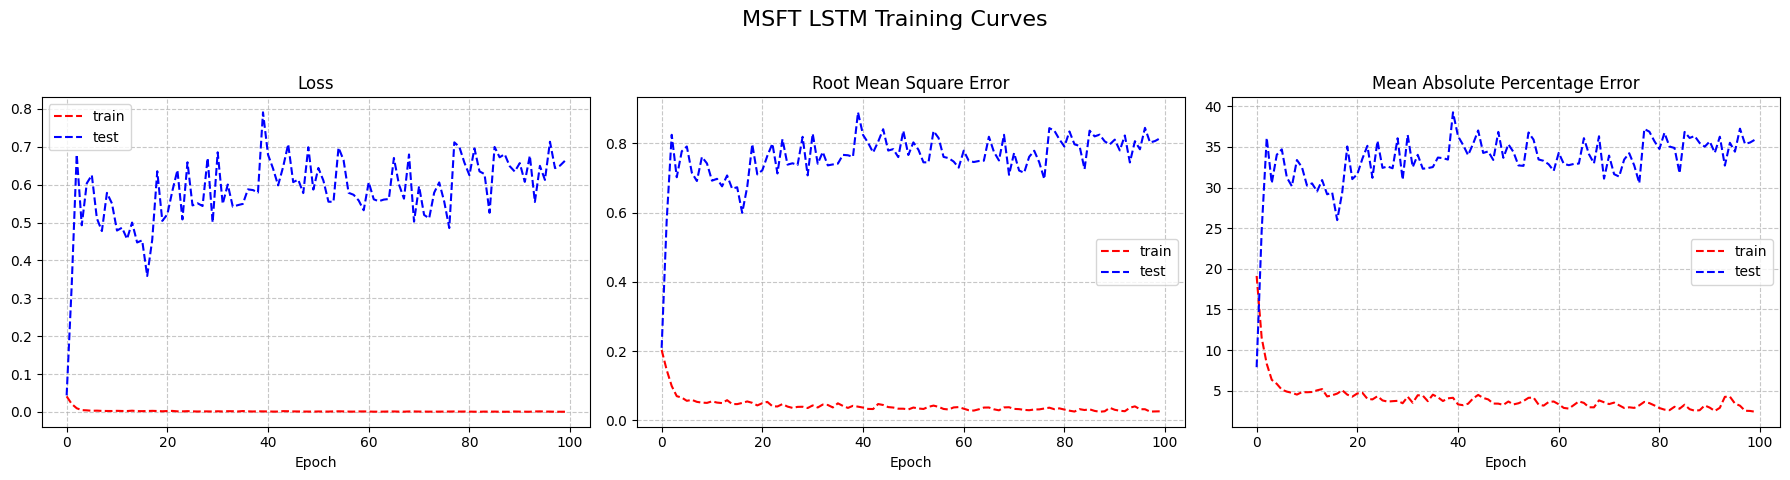


Training GRU on MSFT to capture Loss/RMSE/MAPE curves...


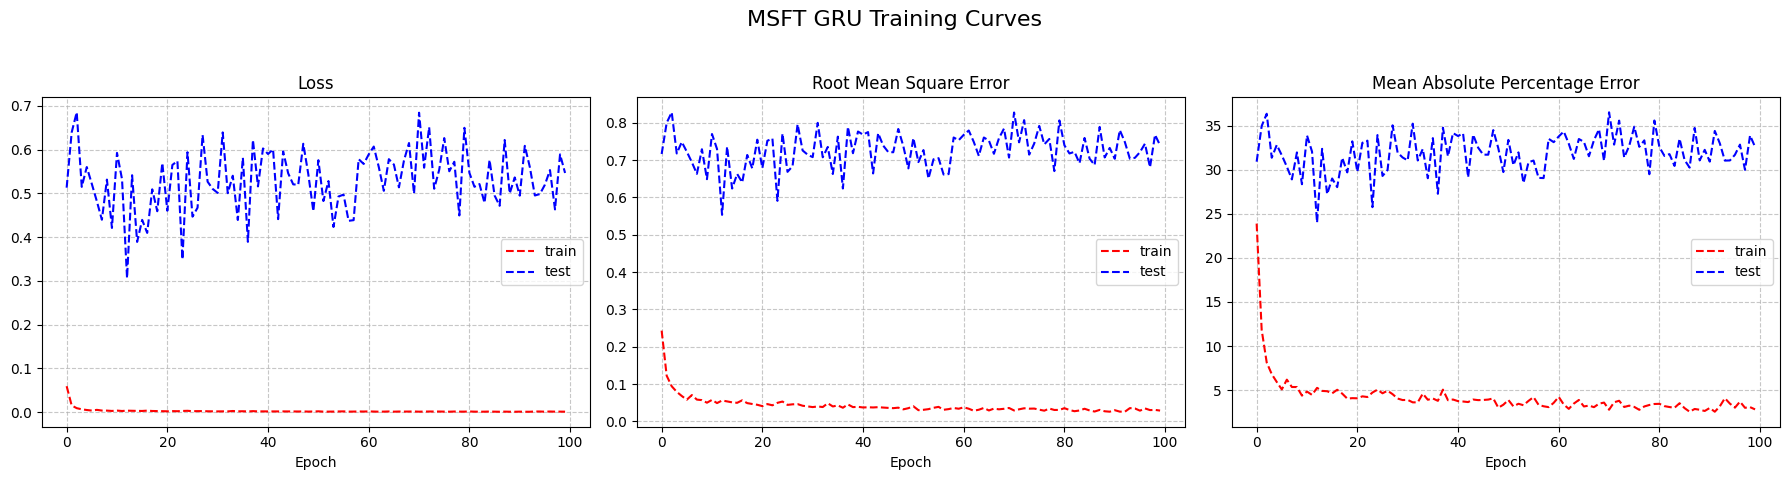


Training Hybrid_LSTM-GRU on MSFT to capture Loss/RMSE/MAPE curves...


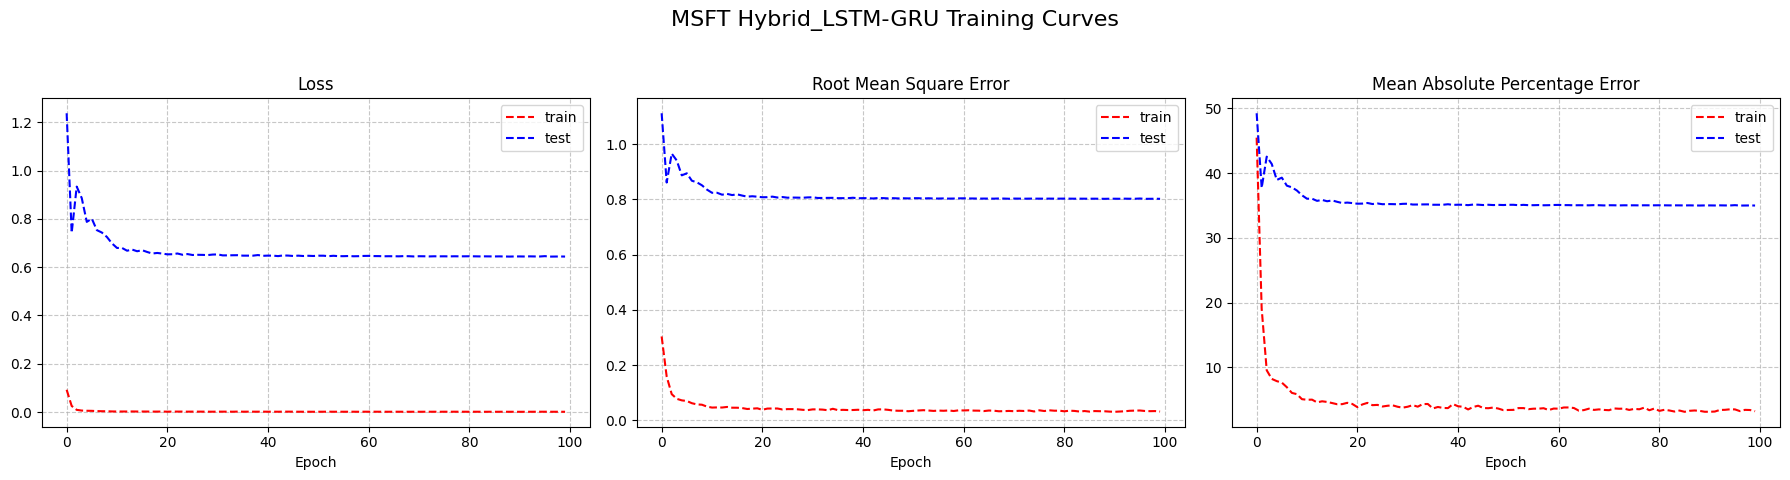

In [57]:
# === Run training-curve capture for every model on this stock (MSFT) ===
model_builders = {
    'LSTM':            build_lstm_model,
    'GRU':             build_simple_gru_model,
    'Hybrid_LSTM-GRU': build_hybrid_model,
}

curve_histories = {}

# Define the directory to save plots
plots_save_dir = 'model_training_curves'
os.makedirs(plots_save_dir, exist_ok=True) # Create the directory if it doesn't exist

for name, fn in model_builders.items():
    print(f"\nTraining {name} on {ticker_symbol} to capture Loss/RMSE/MAPE curves...")
    curve_histories[name] = train_with_curves(fn, name)
    plot_curves(curve_histories[name], name, save_dir=plots_save_dir)

Displaying saved plots for LSTM:
--- LSTM All Curves Plot ---


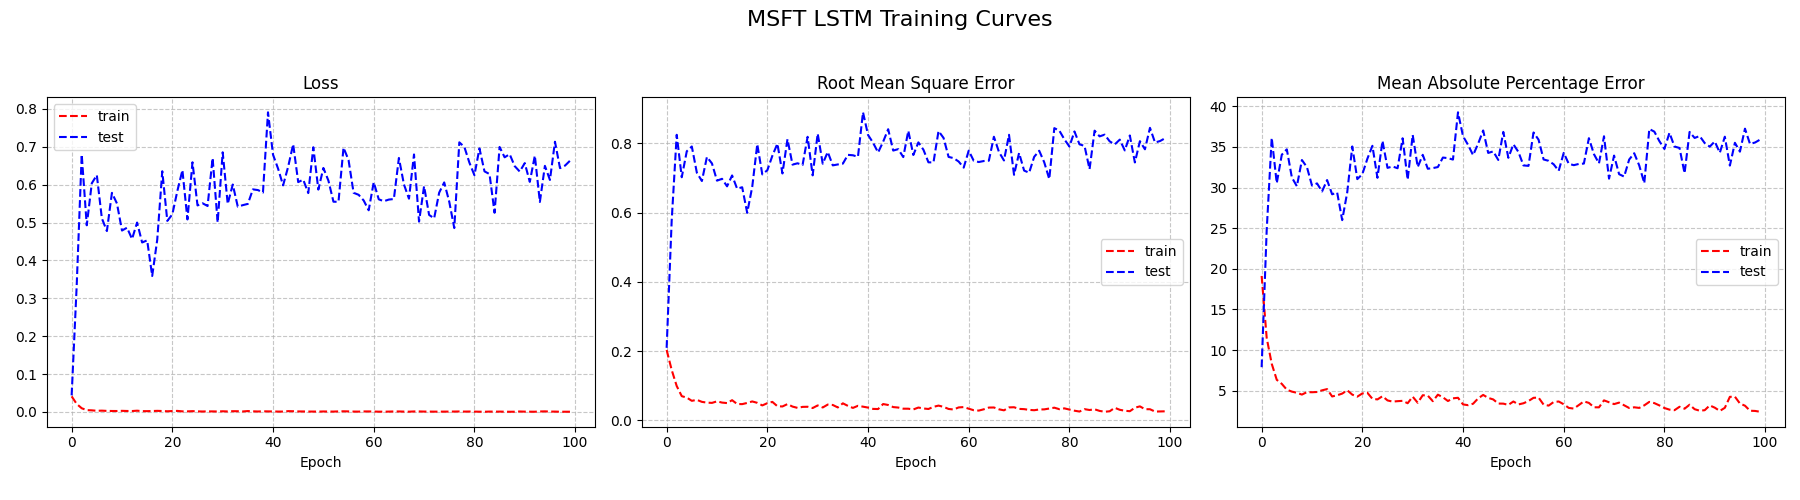

In [58]:
from IPython.display import Image, display
import os

plots_save_dir = 'model_training_curves'
model_name = 'LSTM'

print(f"Displaying saved plots for {model_name}:")

# Display the combined plot
combined_filepath = os.path.join(plots_save_dir, f"{ticker_symbol}_{model_name}_all_curves.png")
if os.path.exists(combined_filepath):
    print(f"--- {model_name} All Curves Plot ---")
    display(Image(filename=combined_filepath))
else:
    print(f"Combined plot not found at {combined_filepath}")


Displaying saved plots for GRU:
--- GRU All Curves Plot ---


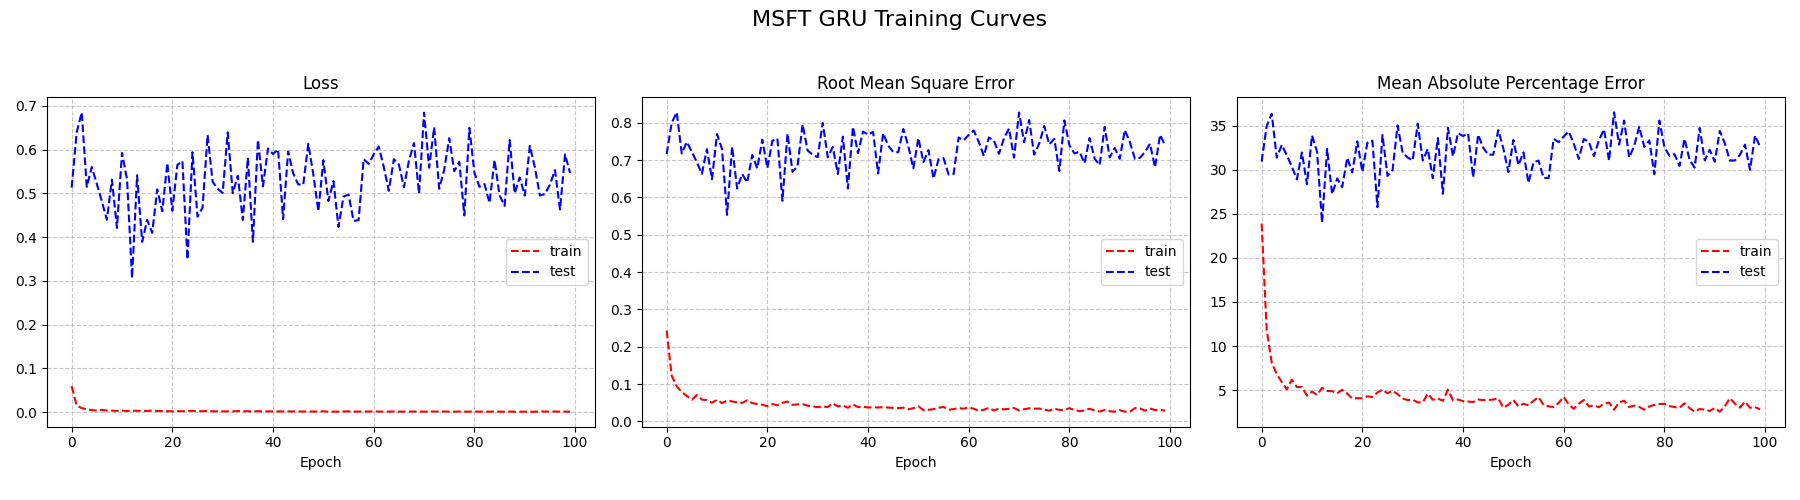


Displaying saved plots for Hybrid_LSTM-GRU:
--- Hybrid_LSTM-GRU All Curves Plot ---


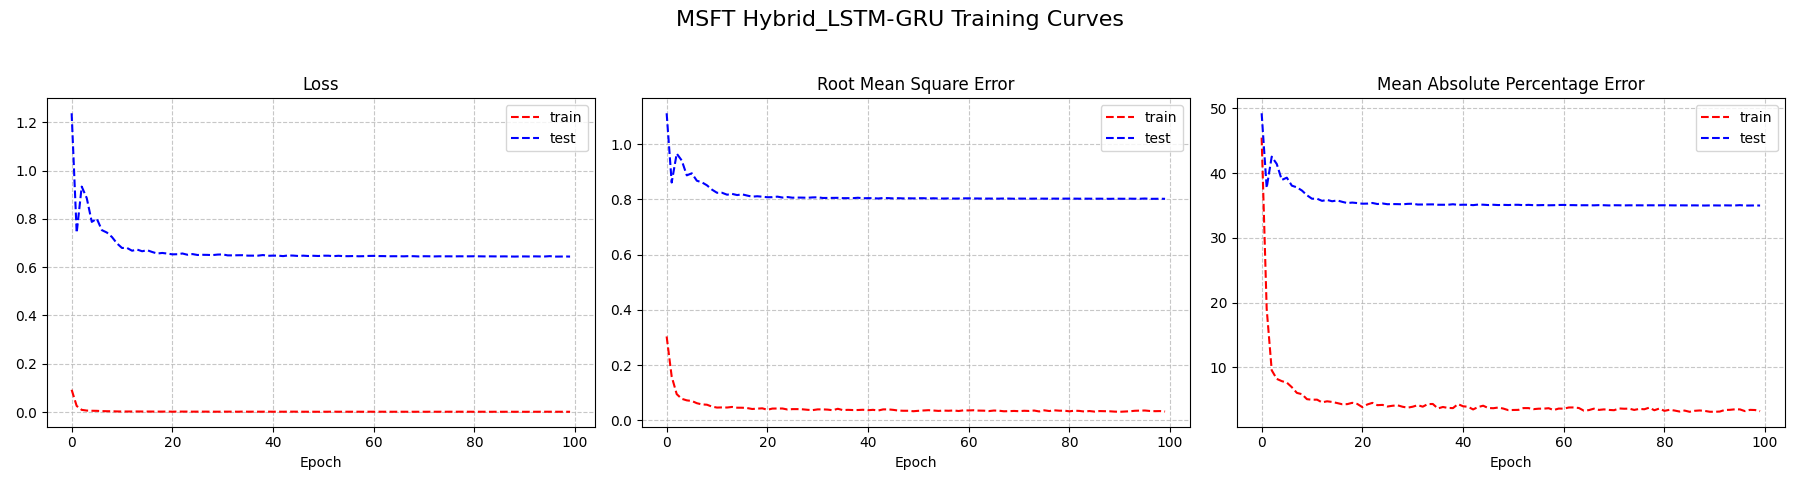

In [59]:
from IPython.display import Image, display
import os

plots_save_dir = 'model_training_curves'
model_names_to_display = ['GRU', 'Hybrid_LSTM-GRU']

for model_name in model_names_to_display:
    print(f"\nDisplaying saved plots for {model_name}:")

    # Display the combined plot
    combined_filepath = os.path.join(plots_save_dir, f"{ticker_symbol}_{model_name}_all_curves.png")
    if os.path.exists(combined_filepath):
        print(f"--- {model_name} All Curves Plot ---")
        display(Image(filename=combined_filepath))
    else:
        print(f"Combined plot not found at {combined_filepath}")